# Data Preparation - Feature Engineering & Preprocessing Steps


In [64]:
# Upload dataset and read it into a pandas DataFrame
%pip install pandas
import pandas as pd

path = r"C:\Users\ramir\OneDrive\TMU Capstone\HR-Employee-Attrition-Dataset.csv"
df = pd.read_csv(path)
df.head()

Note: you may need to restart the kernel to use updated packages.


,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,...,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,...,4,80,1,6,3,3,2,2,2,2


## Step 1: Feature Selection & Data Cleaning
Based on Univariate and Bivariate analysis, remove attributes that either lack predictive variance or introduce unnecessary multicollinearity:
* Zero Variance: EmployeeCount, StandardHours, and Over18 are constant for all records.
* Unique Identifiers: EmployeeNumber is a non-predictive ID.
* Low Information Gain: PerformanceRating is heavily skewed (mostly 3s and 4s).
* Multicollinearity Management: * YearsInCurrentRole and YearsWithCurrManager are dropped due to high correlation (>0.70) with YearsAtCompany.
* Department is removed because JobRole captures the same context with better granularity.


In [65]:
# Dimensionality reduction: remove specified columns
columns_to_remove = ['EmployeeCount', 'StandardHours', 'Over18', 'EmployeeNumber', 
                     'PerformanceRating', 'YearsInCurrentRole', 'YearsWithCurrManager', 'Department']

df = df.drop(columns=columns_to_remove)
print(f"Dataset shape after removing columns: {df.shape}")
df.head()

Dataset shape after removing columns: (1470, 27)


,Age,Attrition,BusinessTravel,DailyRate,DistanceFromHome,Education,EducationField,EnvironmentSatisfaction,Gender,HourlyRate,...,NumCompaniesWorked,OverTime,PercentSalaryHike,RelationshipSatisfaction,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsSinceLastPromotion
0,41,Yes,Travel_Rarely,1102,1,2,Life Sciences,2,Female,94,...,8,Yes,11,1,0,8,0,1,6,0
1,49,No,Travel_Frequently,279,8,1,Life Sciences,3,Male,61,...,1,No,23,4,1,10,3,3,10,1
2,37,Yes,Travel_Rarely,1373,2,2,Other,4,Male,92,...,6,Yes,15,2,0,7,3,3,0,0
3,33,No,Travel_Frequently,1392,3,4,Life Sciences,4,Female,56,...,1,Yes,11,3,0,8,3,3,8,3
4,27,No,Travel_Rarely,591,2,1,Medical,1,Male,40,...,9,No,12,4,1,6,3,3,2,2


## Step 2: Create new features to translate HR domain knowledge into a format the model can better "understand

![alt text](image-3.png)

In [66]:
# Engineer new feature: IncomePerAge
df['IncomePerAge'] = df['MonthlyIncome'] / df['Age']

print(f"Dataset shape: {df.shape}")
print("\nIncomePerAge feature added successfully.")
df[['Age', 'MonthlyIncome', 'IncomePerAge']].head()

Dataset shape: (1470, 28)

IncomePerAge feature added successfully.


,Age,MonthlyIncome,IncomePerAge
0,41,5993,146.170732
1,49,5130,104.693878
2,37,2090,56.486486
3,33,2909,88.151515
4,27,3468,128.444444


In [67]:
# Engineer new feature: TenureRatio
df['TenureRatio'] = df['YearsAtCompany'] / df['TotalWorkingYears']

print(f"Dataset shape: {df.shape}")
print("\nTenureRatio feature added successfully.")
df[['YearsAtCompany', 'TotalWorkingYears', 'TenureRatio']].head()

Dataset shape: (1470, 29)

TenureRatio feature added successfully.


,YearsAtCompany,TotalWorkingYears,TenureRatio
0,6,8,0.750000
1,10,10,1.000000
2,0,7,0.000000
3,8,8,1.000000
4,2,6,0.333333


In [68]:
# Engineer new feature: IncomePerEducation
df['IncomePerEducation'] = df['MonthlyIncome'] / df['Education']

print(f"Dataset shape: {df.shape}")
print("\nIncomePerEducation feature added successfully.")
df[['Education', 'MonthlyIncome', 'IncomePerEducation']].head()

Dataset shape: (1470, 30)

IncomePerEducation feature added successfully.


,Education,MonthlyIncome,IncomePerEducation
0,2,5993,2996.50
1,1,5130,5130.00
2,2,2090,1045.00
3,4,2909,727.25
4,1,3468,3468.00


In [71]:
# Engineer new feature: HolisticSatisfactionIndex
df['HolisticSatisfactionIndex'] = (df['EnvironmentSatisfaction'] + df['JobSatisfaction'] + df['RelationshipSatisfaction'] + df['WorkLifeBalance']) / 4

print(f"Dataset shape: {df.shape}")
print("\nHolisticSatisfactionIndex feature added successfully.")
df[['EnvironmentSatisfaction', 'JobSatisfaction', 'RelationshipSatisfaction', 'WorkLifeBalance', 'HolisticSatisfactionIndex']].head()

Dataset shape: (1470, 31)

HolisticSatisfactionIndex feature added successfully.


,EnvironmentSatisfaction,JobSatisfaction,RelationshipSatisfaction,WorkLifeBalance,HolisticSatisfactionIndex
0,2,4,1,1,2.00
1,3,2,4,3,3.00
2,4,3,2,3,3.00
3,4,3,3,3,3.25
4,1,2,4,3,2.50


## Step 3: Stabilization (Log-Transformation)
Apply the Log1p method to skewed attributes identified in the Univariate analysis (e.g., MonthlyIncome, TotalWorkingYears). This stabilizes variance and pushes the distribution toward normality, which is critical for the stability of our Logistic Regression baseline.

In [72]:
#Log – transform skewed attributes
import numpy as np

# Log-transform selected skewed numeric columns
log_cols = [
    "DistanceFromHome",
    "MonthlyIncome",
    "NumCompaniesWorked",
    "PercentSalaryHike",
    "TotalWorkingYears",
    "YearsAtCompany",
    "YearsSinceLastPromotion",
]

# Apply log1p safely (for non-negative values)
for col in log_cols:
    if (df[col] < 0).any():
        raise ValueError(f"Column '{col}' contains negative values; cannot apply log1p safely.")
    df[col] = np.log1p(df[col])

print("Log transformation completed for selected columns.")
print(f"\nDataset shape: {df.shape}")
df[log_cols].head()

Log transformation completed for selected columns.

Dataset shape: (1470, 31)


,DistanceFromHome,MonthlyIncome,NumCompaniesWorked,PercentSalaryHike,TotalWorkingYears,YearsAtCompany,YearsSinceLastPromotion
0,0.526589,2.271973,1.162283,1.248441,1.162283,1.080418,0.000000
1,1.162283,2.255814,0.526589,1.429846,1.223156,1.223156,0.526589
2,0.741276,2.157027,1.080418,1.327761,1.124748,0.000000,0.000000
3,0.869742,2.194544,0.526589,1.248441,1.162283,1.162283,0.869742
4,0.741276,2.213931,1.194706,1.271150,1.080418,0.741276,0.741276


## Step 4: Categorical Encoding
To prepare the data for machine learning, we address three types of categorical data:
* Binary: Attrition (Target), Gender, and OverTime → (0, 1).
* Nominal (One-Hot): EducationField, JobRole, and MaritalStatus → (Dummy variables).
* Ordinal: BusinessTravel → (0: Non-Travel, 1: Rarely, 2: Frequently).
* Note: Other ordinal features like JobSatisfaction and JobLevel are already encoded numerically in the raw data.

In [73]:
# Categorical Binary Encoding: Convert Attrition (Target), Gender, and OverTime into 0s and 1s
df['Attrition'] = df['Attrition'].map({'Yes': 1, 'No': 0})
df['Gender'] = df['Gender'].map({'Male': 1, 'Female': 0})
df['OverTime'] = df['OverTime'].map({'Yes': 1, 'No': 0})

print("Binary encoding completed.")
print(f"\nAttrition distribution:\n{df['Attrition'].value_counts()}")
print(f"\nGender distribution:\n{df['Gender'].value_counts()}")
print(f"\nOverTime distribution:\n{df['OverTime'].value_counts()}")
df.head()

Binary encoding completed.

Attrition distribution:
Attrition
0    1233
1     237
Name: count, dtype: int64

Gender distribution:
Gender
1    882
0    588
Name: count, dtype: int64

OverTime distribution:
OverTime
0    1054
1     416
Name: count, dtype: int64


,Age,Attrition,BusinessTravel,DailyRate,DistanceFromHome,Education,EducationField,EnvironmentSatisfaction,Gender,HourlyRate,...,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsSinceLastPromotion,IncomePerAge,TenureRatio,IncomePerEducation,HolisticSatisfactionIndex
0,41,1,Travel_Rarely,1102,0.526589,2,Life Sciences,2,0,94,...,0,1.162283,0,1,1.080418,0.000000,146.170732,0.750000,2996.50,2.00
1,49,0,Travel_Frequently,279,1.162283,1,Life Sciences,3,1,61,...,1,1.223156,3,3,1.223156,0.526589,104.693878,1.000000,5130.00,3.00
2,37,1,Travel_Rarely,1373,0.741276,2,Other,4,1,92,...,0,1.124748,3,3,0.000000,0.000000,56.486486,0.000000,1045.00,3.00
3,33,0,Travel_Frequently,1392,0.869742,4,Life Sciences,4,0,56,...,0,1.162283,3,3,1.162283,0.869742,88.151515,1.000000,727.25,3.25
4,27,0,Travel_Rarely,591,0.741276,1,Medical,1,1,40,...,1,1.080418,3,3,0.741276,0.741276,128.444444,0.333333,3468.00,2.50


In [74]:
# One-Hot Encoding for nominal features: EducationField, JobRole, and MaritalStatus with 0s and 1s
df = pd.get_dummies(
    df,
    columns=["EducationField", "JobRole", "MaritalStatus"],
    drop_first=False,
    dtype=int
)

print("One-Hot encoding completed with 0s and 1s.")
print(f"Dataset shape after one-hot encoding: {df.shape}")
df.head()

One-Hot encoding completed with 0s and 1s.
Dataset shape after one-hot encoding: (1470, 46)


,Age,Attrition,BusinessTravel,DailyRate,DistanceFromHome,Education,EnvironmentSatisfaction,Gender,HourlyRate,JobInvolvement,...,JobRole_Laboratory Technician,JobRole_Manager,JobRole_Manufacturing Director,JobRole_Research Director,JobRole_Research Scientist,JobRole_Sales Executive,JobRole_Sales Representative,MaritalStatus_Divorced,MaritalStatus_Married,MaritalStatus_Single
0,41,1,Travel_Rarely,1102,0.526589,2,2,0,94,3,...,0,0,0,0,0,1,0,0,0,1
1,49,0,Travel_Frequently,279,1.162283,1,3,1,61,2,...,0,0,0,0,1,0,0,0,1,0
2,37,1,Travel_Rarely,1373,0.741276,2,4,1,92,2,...,1,0,0,0,0,0,0,0,0,1
3,33,0,Travel_Frequently,1392,0.869742,4,4,0,56,3,...,0,0,0,0,1,0,0,0,1,0
4,27,0,Travel_Rarely,591,0.741276,1,1,1,40,3,...,1,0,0,0,0,0,0,0,1,0


In [75]:
# Ordinal encoding for BusinessTravel
business_travel_map = {
    "Non-Travel": 0,
    "Travel_Rarely": 1,
    "Travel_Frequently": 2
}

df["BusinessTravel"] = df["BusinessTravel"].map(business_travel_map)

print("Ordinal encoding completed.")
print(df["BusinessTravel"].value_counts(dropna=False))
df.head()

Ordinal encoding completed.
BusinessTravel
1    1043
2     277
0     150
Name: count, dtype: int64


,Age,Attrition,BusinessTravel,DailyRate,DistanceFromHome,Education,EnvironmentSatisfaction,Gender,HourlyRate,JobInvolvement,...,JobRole_Laboratory Technician,JobRole_Manager,JobRole_Manufacturing Director,JobRole_Research Director,JobRole_Research Scientist,JobRole_Sales Executive,JobRole_Sales Representative,MaritalStatus_Divorced,MaritalStatus_Married,MaritalStatus_Single
0,41,1,1,1102,0.526589,2,2,0,94,3,...,0,0,0,0,0,1,0,0,0,1
1,49,0,2,279,1.162283,1,3,1,61,2,...,0,0,0,0,1,0,0,0,1,0
2,37,1,1,1373,0.741276,2,4,1,92,2,...,1,0,0,0,0,0,0,0,0,1
3,33,0,2,1392,0.869742,4,4,0,56,3,...,0,0,0,0,1,0,0,0,1,0
4,27,0,1,591,0.741276,1,1,1,40,3,...,1,0,0,0,0,0,0,0,1,0


## Step 5: Training Strategy & Model Selection
* Train-Test Split: An 80/20 split is performed before scaling or SMOTE. This prevents data leakage, ensuring scaling parameters are derived solely from the training distribution.
* Scaling: StandardScaler is applied to normalize features for the Logistic Regression baseline.
* Class Imbalance: SMOTE (Synthetic Minority Over-sampling Technique) is utilized to ensure the model doesn't over-fit to the majority "No Attrition" class.

In [77]:
#Train-Test Split
from sklearn.model_selection import train_test_split

X = df.drop(columns=['Attrition'])
y = df['Attrition']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Training set size: {X_train.shape}")
print(f"Testing set size: {X_test.shape}")
print(f"\nTarget distribution in training set:\n{y_train.value_counts()}")
print(f"\nTarget distribution in testing set:\n{y_test.value_counts()}")

Training set size: (1176, 45)
Testing set size: (294, 45)

Target distribution in training set:
Attrition
0    978
1    198
Name: count, dtype: int64

Target distribution in testing set:
Attrition
0    255
1     39
Name: count, dtype: int64


In [78]:
#Feature Scaling: StandardScaler for numeric features
from sklearn.preprocessing import StandardScaler

numeric_cols = X_train.select_dtypes(include='number').columns

scaler = StandardScaler()

X_train_scaled = X_train.copy()
X_test_scaled = X_test.copy()

X_train_scaled[numeric_cols] = scaler.fit_transform(X_train[numeric_cols])
X_test_scaled[numeric_cols] = scaler.transform(X_test[numeric_cols])

print("StandardScaler applied to numeric features.")
print(f"X_train_scaled shape: {X_train_scaled.shape}")
print(f"X_test_scaled shape: {X_test_scaled.shape}")
X_train_scaled.head()

StandardScaler applied to numeric features.
X_train_scaled shape: (1176, 45)
X_test_scaled shape: (294, 45)


,Age,BusinessTravel,DailyRate,DistanceFromHome,Education,EnvironmentSatisfaction,Gender,HourlyRate,JobInvolvement,JobLevel,...,JobRole_Laboratory Technician,JobRole_Manager,JobRole_Manufacturing Director,JobRole_Research Director,JobRole_Research Scientist,JobRole_Sales Executive,JobRole_Sales Representative,MaritalStatus_Divorced,MaritalStatus_Married,MaritalStatus_Single
1097,-1.388559,-0.184671,-1.108139,1.170531,-0.863356,0.279706,0.814473,-0.472832,-1.012340,-0.932274,...,2.182821,-0.268355,-0.316376,-0.247733,-0.509019,-0.524870,-0.260998,1.845127,-0.937334,-0.662882
727,-2.040738,-2.073134,-1.263481,-0.073764,-0.863356,-0.639104,0.814473,0.309374,0.389912,-0.932274,...,-0.458123,-0.268355,-0.316376,-0.247733,1.964562,-0.524870,-0.260998,-0.541968,-0.937334,1.508564
254,-0.845077,-0.184671,1.103647,1.133292,-0.863356,1.198515,0.814473,-1.059487,0.389912,-0.025447,...,-0.458123,-0.268355,-0.316376,-0.247733,-0.509019,1.905235,-0.260998,1.845127,-0.937334,-0.662882
1175,0.241886,-0.184671,-0.758001,0.722312,0.099933,1.198515,0.814473,-0.032841,0.389912,-0.025447,...,-0.458123,-0.268355,3.160800,-0.247733,-0.509019,-0.524870,-0.260998,-0.541968,1.066856,-0.662882
1341,-0.627685,-0.184671,-1.204303,1.133292,0.099933,-0.639104,0.814473,1.091580,0.389912,-0.025447,...,2.182821,-0.268355,-0.316376,-0.247733,-0.509019,-0.524870,-0.260998,1.845127,-0.937334,-0.662882


In [79]:
# Class imbalance of target variable

from imblearn.over_sampling import SMOTE

# SMOTE does not support missing values, so fill any NaNs in the training data only
X_train_smote_input = X_train_scaled.fillna(X_train_scaled.median())

smote = SMOTE(random_state=42)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train_smote_input, y_train)

# Preserve pandas structure
X_train_resampled = pd.DataFrame(X_train_resampled, columns=X_train_scaled.columns)
y_train_resampled = pd.Series(y_train_resampled, name=y_train.name)

print("SMOTE applied to training data only.")
print(f"Original training shape: {X_train_scaled.shape}, {y_train.shape}")
print(f"Resampled training shape: {X_train_resampled.shape}, {y_train_resampled.shape}")
print("\nClass distribution after SMOTE:")
print(y_train_resampled.value_counts())

SMOTE applied to training data only.
Original training shape: (1176, 45), (1176,)
Resampled training shape: (1956, 45), (1956,)

Class distribution after SMOTE:
Attrition
0    978
1    978
Name: count, dtype: int64


# Model Evaluation Process


## Strategic Recommendations
* For RQ1 (Identifying high-risk employees): For the purpose of identifying high-risk employees, Logistic Regression is the primary model of choice. While its overall accuracy (77.55%) is lower than the ensemble models, it possesses the highest Recall (0.5897). In the context of Research Question 1, the model’s "Sensitivity" (Recall) is the priority metric because it represents the organization’s ability to detect turnover before it occurs.

* For RQ2 (Predictive characteristics of turnover): XGBoost is the preferred model for a "Diagnostic Strategy." Its higher F1-score and Precision indicate that it has learned a more "pure" representation of the attrition signal, making its feature importance (SHAP) values a more reliable guide for policy-level changes.

In [80]:
#Logistic Regression
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix

# Initialize and train Logistic Regression
log_reg = LogisticRegression(random_state=42, max_iter=1000)
log_reg.fit(X_train_resampled, y_train_resampled)

# Handle any NaNs in test set before prediction
X_test_eval = X_test_scaled.fillna(X_train_resampled.median(numeric_only=True))

# Predict and evaluate
y_pred = log_reg.predict(X_test_eval)

print("Classification Report:")
print(classification_report(y_test, y_pred))

print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))

Classification Report:
              precision    recall  f1-score   support

           0       0.93      0.80      0.86       255
           1       0.32      0.59      0.41        39

    accuracy                           0.78       294
   macro avg       0.62      0.70      0.64       294
weighted avg       0.85      0.78      0.80       294

Confusion Matrix:
[[205  50]
 [ 16  23]]


In [81]:

#Random Forest with Hyperparameter Tuning
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV

# Define model and hyperparameter grid
rf = RandomForestClassifier(random_state=42, n_jobs=-1)
param_grid = {
    "n_estimators": [100, 200, 300, 400, 500],
    "max_depth": [5, 10, 15, 20]
}

# Grid search on resampled training data
grid_search = GridSearchCV(
    estimator=rf,
    param_grid=param_grid,
    cv=5,
    scoring="f1",
    n_jobs=-1,
    verbose=1
)
grid_search.fit(X_train_resampled, y_train_resampled)

# Best model
best_rf = grid_search.best_estimator_
print("Best params:", grid_search.best_params_)

# Evaluate on scaled test set (with NaN handling)
X_test_rf = X_test_scaled.fillna(X_train_resampled.median(numeric_only=True))
y_pred_rf = best_rf.predict(X_test_rf)

print("\nClassification Report:")
print(classification_report(y_test, y_pred_rf))

print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_rf))

Fitting 5 folds for each of 20 candidates, totalling 100 fits
Best params: {'max_depth': 15, 'n_estimators': 500}

Classification Report:
              precision    recall  f1-score   support

           0       0.90      0.98      0.94       255
           1       0.75      0.31      0.44        39

    accuracy                           0.89       294
   macro avg       0.83      0.65      0.69       294
weighted avg       0.88      0.89      0.87       294

Confusion Matrix:
[[251   4]
 [ 27  12]]


In [82]:
#XGBoost Classifier with Hyperparameter Tuning
from xgboost import XGBClassifier
from sklearn.metrics import roc_auc_score

# Initialize XGBoost classifier
xgb_clf = XGBClassifier(
    random_state=42,
    eval_metric="logloss"
)

# Parameter grid
xgb_param_grid = {
    "learning_rate": [0.01, 0.1, 0.2],
    "max_depth": [3, 6, 10],
    "subsample": [0.8]
}

# 5-fold CV grid search
xgb_grid = GridSearchCV(
    estimator=xgb_clf,
    param_grid=xgb_param_grid,
    cv=5,
    scoring="roc_auc",
    n_jobs=-1,
    verbose=1
)
xgb_grid.fit(X_train_resampled, y_train_resampled)

print("Best params:", xgb_grid.best_params_)

# Evaluate final ROC-AUC on test set
best_xgb = xgb_grid.best_estimator_
X_test_xgb = X_test_scaled.fillna(X_train_resampled.median(numeric_only=True))
y_proba_xgb = best_xgb.predict_proba(X_test_xgb)[:, 1]
final_roc_auc = roc_auc_score(y_test, y_proba_xgb)

print("Final ROC-AUC score:", final_roc_auc)

Fitting 5 folds for each of 9 candidates, totalling 45 fits
Best params: {'learning_rate': 0.2, 'max_depth': 10, 'subsample': 0.8}
Final ROC-AUC score: 0.7888386123680241


,Model,Accuracy,Precision,Recall,F1-score
0,Logistic Regression,0.775510,0.315068,0.589744,0.410714
1,Random Forest,0.894558,0.750000,0.307692,0.436364
2,XGBoost,0.897959,0.736842,0.358974,0.482759


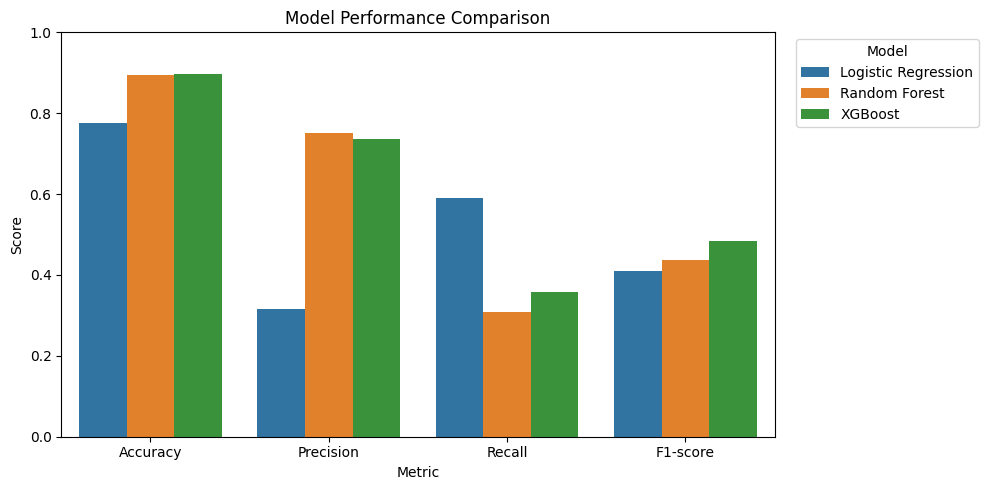

Recommendation: Use XGBoost, as it provides the strongest F1-score balance between precision and recall.


In [84]:
#Model metrics comparison and recommendation
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
import seaborn as sns

import matplotlib.pyplot as plt

# Ensure XGBoost class predictions exist
if "y_pred_xgb" not in globals():
    y_pred_xgb = (y_proba_xgb >= 0.5).astype(int)

# Build comparison table
model_results = pd.DataFrame({
    "Model": ["Logistic Regression", "Random Forest", "XGBoost"],
    "Accuracy": [
        accuracy_score(y_test, y_pred),
        accuracy_score(y_test, y_pred_rf),
        accuracy_score(y_test, y_pred_xgb),
    ],
    "Precision": [
        precision_score(y_test, y_pred, zero_division=0),
        precision_score(y_test, y_pred_rf, zero_division=0),
        precision_score(y_test, y_pred_xgb, zero_division=0),
    ],
    "Recall": [
        recall_score(y_test, y_pred, zero_division=0),
        recall_score(y_test, y_pred_rf, zero_division=0),
        recall_score(y_test, y_pred_xgb, zero_division=0),
    ],
    "F1-score": [
        f1_score(y_test, y_pred, zero_division=0),
        f1_score(y_test, y_pred_rf, zero_division=0),
        f1_score(y_test, y_pred_xgb, zero_division=0),
    ],
})

display(model_results)

# Plot with seaborn
plot_df = model_results.melt(id_vars="Model", var_name="Metric", value_name="Score")
plt.figure(figsize=(10, 5))
sns.barplot(data=plot_df, x="Metric", y="Score", hue="Model")
plt.title("Model Performance Comparison")
plt.ylim(0, 1)
plt.legend(title="Model", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

# Recommendation (prioritize F1 for imbalanced attrition classification)
best_model = model_results.loc[model_results["F1-score"].idxmax(), "Model"]
print(f"Recommendation: Use {best_model}, as it provides the strongest F1-score balance between precision and recall.")

# Post Model Interpretation


### RQ1: Identifying Employees Most Likely to Leave

This section uses the trained XGBoost model to estimate which employees are at the highest risk of voluntary attrition.

- Missing values in the test set are filled using median values from the resampled training data.
- The model predicts attrition probability for each employee, where class 1 represents Attrition.
- A risk table is created with two fields:
  - Employee ID
  - Attrition Probability
- Employees are categorized by risk level:
  - Low: probability below 0.50
  - Medium: probability from 0.50 to below 0.80
  - High: probability 0.80 and above
- The table is sorted in descending order of attrition probability.
- The top 20 highest-risk employees are displayed for targeted retention action.

This makes the model output actionable by turning probabilities into a ranked risk list that supports HR decision-making.

In [85]:
# RQ1 - Which employees are most likely to voluntarily leave the organization

# Prepare test set for XGBoost prediction (consistent with prior NaN handling)
X_test_xgb = X_test_scaled.fillna(X_train_resampled.median(numeric_only=True))

# Predict attrition probabilities (class 1 = Attrition)
y_proba_xgb = best_xgb.predict_proba(X_test_xgb)[:, 1]

# Build risk table (using test index as Employee ID)
risk_df = pd.DataFrame({
    "Employee ID": X_test_xgb.index,
    "Attrition Probability": y_proba_xgb
})

# Assign risk category
risk_df["Risk Category"] = pd.cut(
    risk_df["Attrition Probability"],
    bins=[-float("inf"), 0.5, 0.8, float("inf")],
    labels=["Low", "Medium", "High"],
    right=False
)

# Sort highest-risk employees first
risk_df = risk_df.sort_values("Attrition Probability", ascending=False).reset_index(drop=True)

risk_df.head(20)

,Employee ID,Attrition Probability,Risk Category
0,1057,0.980331,High
1,892,0.968187,High
2,1192,0.964550,High
3,946,0.940695,High
4,363,0.939428,High
5,591,0.937653,High
6,915,0.930289,High
7,777,0.875589,High
8,921,0.854112,High
9,1167,0.833814,High


## RQ2 - What are the most predictive characteristics of voluntary turnover?

In a SHAP summary plot, color represents the actual feature value:

* Blue means a lower feature value.
* Red means a higher feature value.

The x-axis SHAP value shows direction of impact on prediction:

* Positive SHAP values push the model toward Attrition = Yes.
* Negative SHAP values push the model toward Attrition = No.

StockOptionLevel is one of the top predictors because employees with lower stock option levels tend to receive positive SHAP contributions, which increase predicted turnover risk. In practical terms, weaker equity incentives appear linked to a greater likelihood of voluntary exit in this model.


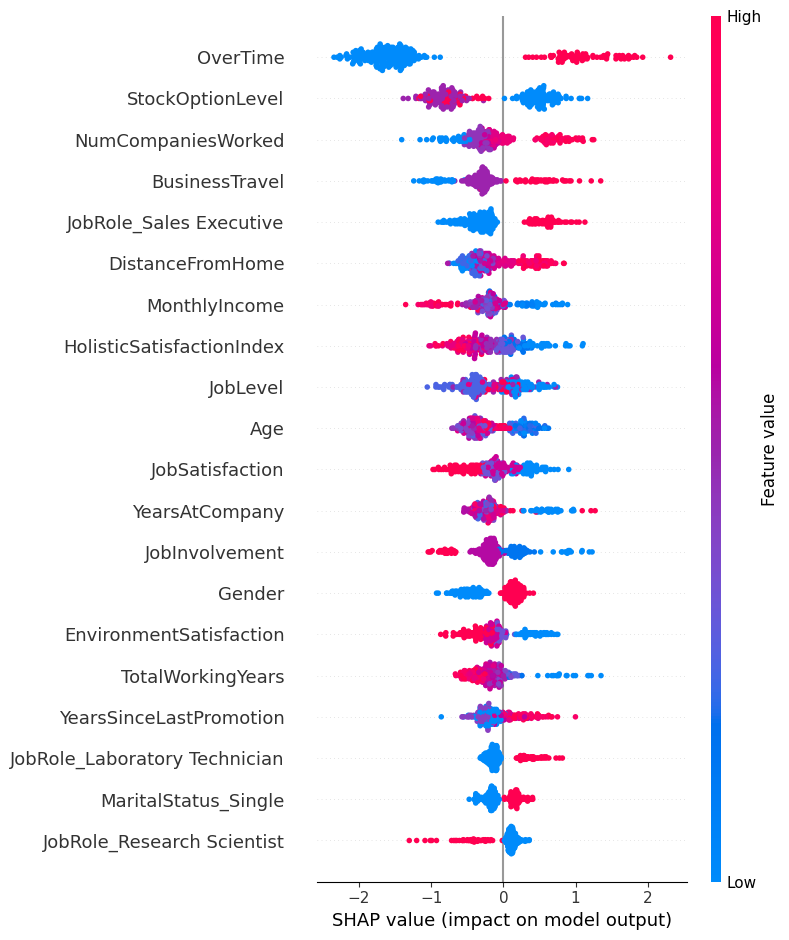

Top 5 most predictive characteristics of voluntary turnover:
1. OverTime (mean |SHAP| = 1.4913)
2. StockOptionLevel (mean |SHAP| = 0.6665)
3. NumCompaniesWorked (mean |SHAP| = 0.4173)
4. BusinessTravel (mean |SHAP| = 0.4159)
5. JobRole_Sales Executive (mean |SHAP| = 0.4095)

Brief summary: The SHAP analysis indicates that the strongest drivers of voluntary turnover in this model are: OverTime, StockOptionLevel, NumCompaniesWorked, BusinessTravel, JobRole_Sales Executive. These features have the largest average impact on predicted attrition risk.


In [ ]:
# RQ2 - What are the most predictive characteristics of voluntary turnover?

import shap

# Prepare test data for SHAP (same NaN strategy used in evaluation)
X_test_shap = X_test_scaled.fillna(X_train_resampled.median(numeric_only=True))

# SHAP values for trained XGBoost model
explainer = shap.TreeExplainer(best_xgb)
shap_values = explainer.shap_values(X_test_shap)

# Handle SHAP output format across versions
if isinstance(shap_values, list):
    shap_values_to_plot = shap_values[1]  # class 1 (Attrition)
else:
    shap_values_to_plot = shap_values

# Summary plot: global feature impact
shap.summary_plot(shap_values_to_plot, X_test_shap)

# Top 5 predictive features by mean absolute SHAP value
top5 = (
    pd.Series(np.abs(shap_values_to_plot).mean(axis=0), index=X_test_shap.columns)
    .sort_values(ascending=False)
    .head(5)
)

print("Top 5 most predictive characteristics of voluntary turnover:")
for i, (feature, score) in enumerate(top5.items(), 1):
    print(f"{i}. {feature} (mean |SHAP| = {score:.4f})")

print(
    "\nBrief summary: The SHAP analysis indicates that the strongest drivers of voluntary turnover "
    f"in this model are: {', '.join(top5.index.tolist())}. "
    "These features have the largest average impact on predicted attrition risk."
)